# Notebook 03 — NLP MapReduce

Analyse des descriptions textuelles par MapReduce PySpark.
Extraction du top 50 mots les plus frequents pour features ML.

In [17]:
import os

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName('03_nlp_immobilier') \
    .master('local[*]') \
    .config('spark.ui.enabled', 'false') \
    .getOrCreate()
spark.sparkContext.setLogLevel('ERROR')
print('SparkSession pret:', spark.version)

SparkSession pret: 4.1.1


## Etape 1 — Chargement du Parquet nettoye

In [18]:
df = spark.read.parquet('../data/clean')
print(f'Lignes chargees : {df.count()}')
df.select('ville', 'description').show(5, truncate=60)

Lignes chargees : 5336
+------+------------------------------------------------------------+
| ville|                                                 description|
+------+------------------------------------------------------------+
|Nantes|Appartement à vendre 1 pièces NANTES (44).\n\nSitué en pl...|
|Nantes|NANTES, Beaujoire, T1 au 5ème et dernier étage.\n\nNANTES...|
|Nantes|Résidence Affaires.\n\nRéalisez un investissement locatif...|
|Nantes|Appartement de 31,49m2 avec balcon et parking sécurisé - ...|
|Nantes|À VENDRE : Appartement T1 à Nantes libre de toute locatio...|
+------+------------------------------------------------------------+
only showing top 5 rows


## Etape 2 — Tokenisation des descriptions

In [19]:
# Tokenisation : split sur espaces et ponctuation
df_desc = df.select('description').filter(F.length('description') > 0)
df_words = df_desc.select(
    F.explode(F.split(F.lower(F.col('description')), r'[\s\W]+')).alias('mot')
)
df_words = df_words.filter(F.length('mot') > 2)
print(f'Nombre total de tokens : {df_words.count()}')

Nombre total de tokens : 559259


## Etape 3 — Suppression des stopwords francais

In [20]:
stopwords_fr = [
    'les','des','une','est','que','qui','pour','dans','sur','par',
    'avec','tout','plus','mais','son','ses','ces','vous','nous','ils',
    'elle','ont','pas','bien','tres','aussi','cette','comme','peut',
    'leur','dont','donc','voir','avoir','etre','faire','tous','meme',
    'alors','donc','car','sous','tres','apres','avant','lors','sans',
    'entre','vers','chez','celui','celle','ceux','votre','notre',
    'mon','ton','son','lui','beau','belle','bon','bonne','peu',
    'trop','haut','bas','grand','petit','grande','petite','cet','sont','ainsi',
    'france','honoraires','charges','agence','lots','compose'
]

df_filtered = df_words.filter(~F.col('mot').isin(stopwords_fr))
df_filtered = df_filtered.filter(F.col('mot').rlike('^[a-zà-ÿéèêëàâäùûüôöîïç]{3,}$'))
print(f'Tokens apres suppression stopwords : {df_filtered.count()}')

Tokens apres suppression stopwords : 410012


## Etape 4 — MapReduce : (mot, 1) -> reduceByKey -> (mot, total)

In [21]:
# MapReduce via groupBy + count (equivalent reduceByKey)
# Map : chaque mot -> (mot, 1)
# Reduce : sum par mot
df_counts = df_filtered.groupBy('mot').count().orderBy(F.desc('count'))
print('MapReduce termine. Top 10 mots :')
df_counts.show(10)

MapReduce termine. Top 10 mots :


+-----------+-----+
|        mot|count|
+-----------+-----+
|appartement| 7554|
|       situ| 4312|
|      salle| 4056|
|       tage| 3778|
|    cuisine| 3754|
|        vie| 3382|
|   copropri| 2859|
|   chambres| 2614|
|       jour| 2557|
|       deux| 2432|
+-----------+-----+
only showing top 10 rows


## Etape 5 — Extraction du top 50 mots

In [22]:
top50_df = df_counts.limit(50)
top50_pd = top50_df.toPandas()
print('Top 50 mots extraits :', len(top50_pd))
print(top50_pd)

Top 50 mots extraits : 50
             mot  count
0    appartement   7554
1           situ   4312
2          salle   4056
3           tage   3778
4        cuisine   3754
5            vie   3382
6       copropri   2859
7       chambres   2614
8           jour   2557
9           deux   2432
10           eau   2422
11        espace   2412
12          entr   2294
13         calme   2207
14      quartier   2170
15      proximit   2098
16        maison   2086
17      immeuble   2045
18    immobilier   1942
19       sidence   1921
20         expos   1844
21       chambre   1839
22      lumineux   1822
23     commerces   1803
24      terrasse   1765
25          quip   1710
26           rue   1703
27     ascenseur   1699
28       propose   1695
29           ind   1671
30         offre   1653
31         place   1485
32        jardin   1452
33        charge   1427
34        balcon   1422
35        rement   1401
36      bordeaux   1366
37           vue   1366
38          pied   1345
39           a

## Etape 6 — Visualisation : barplot des 20 mots les plus frequents

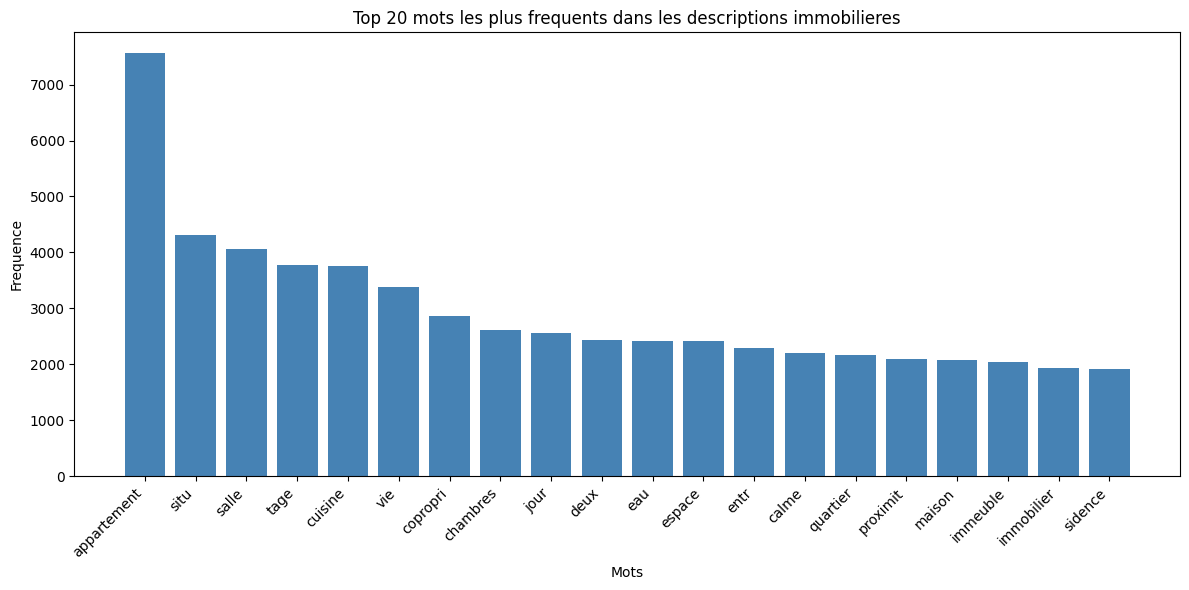

Graphique sauvegarde


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top50_pd['mot'][:20], top50_pd['count'][:20], color='steelblue')
ax.set_xlabel('Mots')
ax.set_ylabel('Frequence')
ax.set_title('Top 20 mots les plus frequents dans les descriptions immobilieres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/barplot_nlp.png', dpi=100)
plt.show()
print('Graphique sauvegarde')

## Etape 7 — Interpretation des resultats NLP

Les mots les plus frequents revelent :
- **Attributs positifs** : calme, lumineux, vue, exclusivit
- **Equipements** : terrasse, balcon, parking, garage, cave
- **Localisation** : quartier, proche, commerces
- **Type de bien** : appartement, maison, studio, duplex

Ces 50 mots serviront de **features binaires** (presence/absence) pour le pipeline ML.

In [24]:
# Récupérer la liste des mots pour le notebook ML
TOP50_FEATURES = []
for row in top50_df.collect():
    TOP50_FEATURES.append(row['mot'])

print('Top 50 mots (à réutiliser dans le notebook 04) :')
print(TOP50_FEATURES)
spark.stop()

Top 50 mots (à réutiliser dans le notebook 04) :
['appartement', 'situ', 'salle', 'tage', 'cuisine', 'vie', 'copropri', 'chambres', 'jour', 'deux', 'eau', 'espace', 'entr', 'calme', 'quartier', 'proximit', 'maison', 'immeuble', 'immobilier', 'sidence', 'expos', 'chambre', 'lumineux', 'commerces', 'terrasse', 'quip', 'rue', 'ascenseur', 'propose', 'ind', 'offre', 'place', 'jardin', 'charge', 'balcon', 'rement', 'bordeaux', 'vue', 'pied', 'agr', 'offrant', 'nantes', 'informations', 'vendeur', 'compl', 'transports', 'cave', 'ouverte', 'site', 'classe']
